# NB2 — Machine Learning
## Parts 3 and 4 · 1:00 – 2:00

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/USER/ml-workshop-2h/blob/main/notebooks/NB2-machine-learning.ipynb)

**Click *Copy to Drive* before you start.**

This notebook is **independent of NB1**. It loads and cleans its own data
below. If anything in NB1 went wrong, it does not matter now — run cell 1
and you are caught up with everyone else.

---
## Cell 1 — run this first, whatever happened in NB1

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"
df = pd.read_csv(URL).dropna().reset_index(drop=True)

print(f"{len(df)} penguins, no missing values.")
df.head()

One line did the whole of Part 2's cleaning: `.dropna()`. You now know what
it cost us (11 rows) and why we accepted that.

---
---
# Part 3 — Concepts, then your first model · 1:00 – 1:30

## The four ideas

**1. Supervised vs unsupervised.** Supervised learning has an *answer key* —
we know each penguin's species and the model learns to reproduce it.
Unsupervised has no answer key; the model finds groupings on its own.
Today is entirely supervised.

**2. Features and labels.** In the table you already know:

- the columns we learn **from** are the **features**, called `X`
- the column we learn **to predict** is the **label**, called `y`

**3. Train / test split.** We hide some rows from the model, then test it on
those. *You do not grade a student on the exact questions they studied.*

**4. Overfitting.** A model can memorise the training rows instead of
learning the pattern. It then scores brilliantly on what it has seen and
badly on anything new. The gap between those two scores is the warning sign.

> Write each of those four in **your own words** in the cell below. Not for
> marks — putting it in your own words is how you find out whether you have it.

*Your definitions (double-click to edit this cell):*

1. Supervised vs unsupervised —
2. Features and labels —
3. Train / test split —
4. Overfitting —

<p align="center">
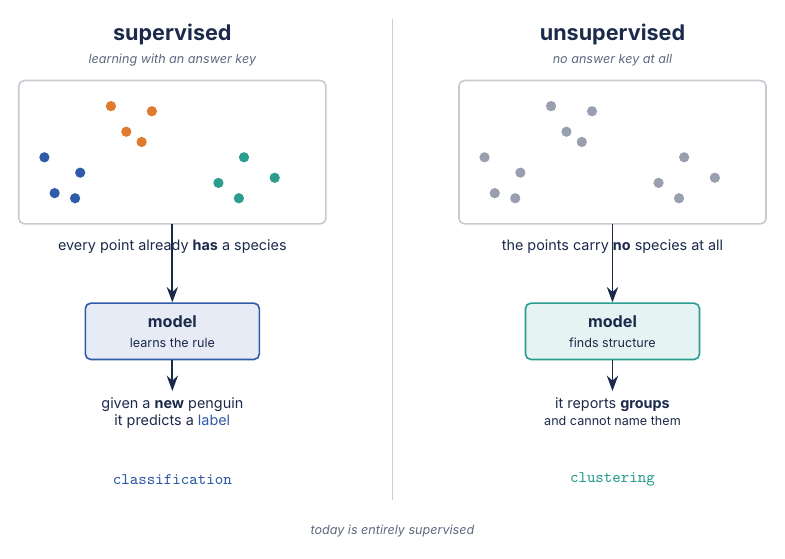
</p>

<p align="center">
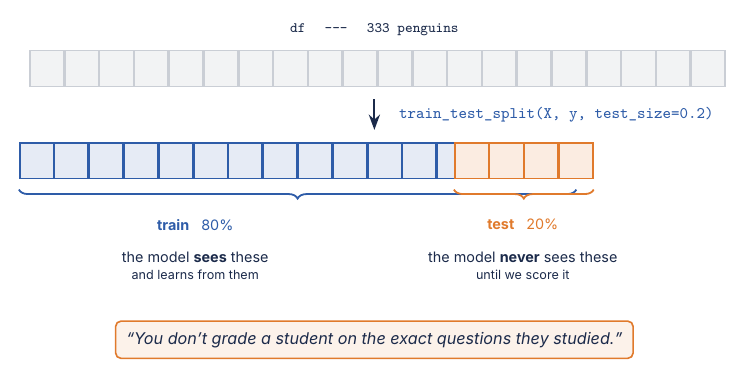
</p>

---
## Features and labels, on our data

In [ ]:
# --- live-code: define X and y ---
# X = three numeric columns (double brackets), y = species

> `X` uses **double** brackets (a DataFrame, many columns), `y` uses **single**
> (a Series, one column). Get this backwards and `.fit()` fails — which is the
> single most common error in the next twenty minutes.

## Split, fit, predict, score

These four lines are the pattern. If you remember nothing else from today,
remember this shape.

In [ ]:
# --- live-code: the split ---
# train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# --- live-code: fit the model ---
# LogisticRegression(max_iter=1000).fit(X_train, y_train)

> **That was it.** `.fit()` is the line the entire workshop was building
> toward. Everything before it was getting the data into a shape this line
> accepts; everything after it is checking whether to believe it.

In [ ]:
# --- live-code: predict and score ---
# model.predict(X_test), accuracy_score(y_test, preds)

---
## Evaluate honestly

Accuracy is one number and it hides things. A confusion matrix shows you
*which* classes it confuses.

In [ ]:
# --- live-code: confusion matrix ---
# ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)

<p align="center">
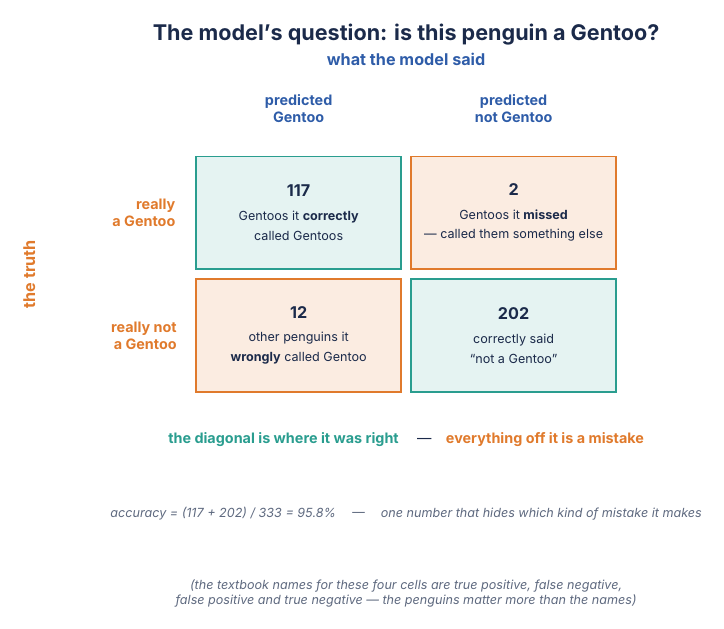
</p>

<div style="border-left:5px solid #2A9D8F;background:#ECF7F5;padding:10px 16px;margin:14px 0;border-radius:4px;">
<div style="color:#2A9D8F;font-weight:700;font-size:12px;letter-spacing:.09em;margin-bottom:4px;">THE POINT</div>
The diagonal is where it was right. Everything off the diagonal is a mistake — and the matrix tells you <i>which</i> pair the model confuses, which a single accuracy number never can.
</div>

### Now look at a penguin it got wrong

Accuracy is a number. A misclassified row is a story.

In [ ]:
# --- live-code: inspect the mistakes ---
# wrong = X_test[preds != y_test]

### Checkpoint

> Our model scores about 97% on the **test** set. Suppose I now score it on
> the **training** set and get 100%. Is that good news?

In [ ]:
# --- live-code: train accuracy vs test accuracy ---
# score the model on X_train too, and compare

---
---
# Part 4 — A second model, and the scaling trap · 1:30 – 2:00

**K-Nearest Neighbors** does not learn an equation. To classify a new
penguin it finds the `K` most similar penguins it has already seen, and
takes a vote.

"Most similar" means **closest** — and that is where it gets interesting.

### First, run it on the raw numbers

In [ ]:
# --- live-code: KNN, unscaled ---
# KNeighborsClassifier(n_neighbors=5), fit, score

That is noticeably worse than logistic regression. **Why?**

Look at the numbers: body mass is in the *thousands*, bill length in the
*tens*. When KNN measures distance, a 500 g difference in mass swamps a 5 mm
difference in bill — so it is effectively using mass alone and ignoring the
other two features entirely.

**Scaling** puts every feature on the same footing.

<p align="center">
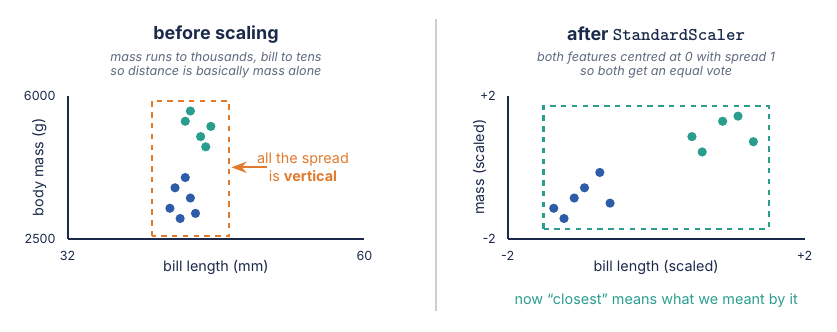
</p>

<div style="border-left:5px solid #2E5CA8;background:#EDF2FA;padding:10px 16px;margin:14px 0;border-radius:4px;">
<div style="color:#2E5CA8;font-weight:700;font-size:12px;letter-spacing:.09em;margin-bottom:4px;">WHY</div>
KNN works out <b>distance</b>: <code>d = sqrt(Δbill² + Δmass²)</code>. For two penguins 5 mm and 500 g apart that is <code>sqrt(25 + 250000)</code> — mass contributes 250 000, bill contributes 25. Bill length is <b>0.01%</b> of the answer.
</div>

In [ ]:
# --- live-code: KNN, scaled ---
# StandardScaler().fit(X_train), transform both, refit

> **Fit the scaler on the training set only.** If you fit it on all the data,
> information from the test set leaks into training and your score becomes a
> flattering lie. This is the most common subtle bug in applied ML.

Models have **preconditions**. KNN needs scaled features; logistic regression
mostly shrugs. Knowing which is which is most of the craft.

### Optional: does K matter?

In [ ]:
# Try a few values of K and see what happens to accuracy.
for k in [1, 3, 5, 15, 50]:
    m = KNeighborsClassifier(n_neighbors=___)
    m.fit(scaler.transform(X_train), y_train)
    print(k, round(accuracy_score(y_test, m.predict(scaler.transform(X_test))), 4))

---
---
# The Titanic challenge — 12 minutes, in pairs

A messier dataset, on purpose. Penguins were tidy; almost nothing real is.

Your job: get from a raw CSV to a score, using the pattern you now know.
**Nobody is going to tell you the steps in order again.**

In [ ]:
tdf = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")
print(tdf.shape)
tdf.head()

### Step 1 — explore

What columns are there? What are you predicting? What is missing?

In [ ]:
# hint: .info(), .isna().sum(), and value_counts() on 'Survived'

### Step 2 — handle the missing `Age`

177 of 891 passengers have no recorded age. You have three options, and
**all three cost something**:

| option | what it costs |
|---|---|
| **drop the rows** | 20% of your data — and they are not a random 20% |
| **fill with a constant** (`0`, `-1`) | invents an age that is not an age |
| **fill with a statistic** (mean, median) | keeps every row, distorts the distribution |

Filling a gap is called **imputation**. The word matters because it is honest
about what you are doing:

<div style="border-left:5px solid #2A9D8F;background:#ECF7F5;padding:10px 16px;margin:14px 0;border-radius:4px;">
<div style="color:#2A9D8F;font-weight:700;font-size:12px;letter-spacing:.09em;margin-bottom:4px;">THE POINT</div>
You are not <i>recovering</i> the missing value. You are <b>inventing</b> one. Every imputed passenger gets the <i>same</i> invented age, so they all pile up in one place.
</div>

Run the cell below to see what a median fill does to the shape of the column
before you decide.

In [ ]:
import matplotlib.pyplot as plt

bins = range(0, 85, 5)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)

ax[0].hist(tdf['Age'].dropna(), bins=bins, color='#2E5CA8')
ax[0].set_title(f"observed  (n={tdf['Age'].notna().sum()})")

ax[1].hist(tdf['Age'].fillna(tdf['Age'].median()), bins=bins, color='#E07A2C')
ax[1].set_title(f"after filling with the median ({tdf['Age'].median():.0f})")

for a in ax:
    a.set_xlabel('age (years)')
ax[0].set_ylabel('passengers')
plt.tight_layout(); plt.show()

print("std before:", round(tdf['Age'].std(), 2))
print("std after: ", round(tdf['Age'].fillna(tdf['Age'].median()).std(), 2))

That spike is 177 people who now share one age. The column looks **less
variable than reality**, and a model reading it will be quietly overconfident
about 28-year-olds.

That may still be the right trade — but it is a trade, and you should be able
to say what you paid.

<div style="border-left:5px solid #E07A2C;background:#FDF2E9;padding:10px 16px;margin:14px 0;border-radius:4px;">
<div style="color:#E07A2C;font-weight:700;font-size:12px;letter-spacing:.09em;margin-bottom:4px;">WATCH OUT</div>
<b>Three rules for imputing.</b><br>1. Fit the imputer on the <b>training set only</b> — otherwise the median carries information from the test set into your model. Same leakage trap as fitting a scaler on all the data.<br>2. <b>Never impute the label.</b> Inventing answers is not cleaning.<br>3. <b>Record what you filled.</b> An <code>Age_was_missing</code> column of 0/1 costs nothing, and on the Titanic it is often predictive on its own — whose age went unrecorded was not random.
</div>

Now pick one and do it. Write one sentence below saying why.

In [ ]:
# option A: tdf = tdf.dropna(subset=['Age'])
# option B: tdf['Age'] = tdf['Age'].fillna(tdf['Age'].median())
# pick one — and write one sentence below saying why

### Step 3 — make `Sex` numeric

scikit-learn cannot do arithmetic on the word `'female'`. Turn that column
into numbers.

In [ ]:
#@title 💡 Hint for step 3 — click to open only if you need it
# A column of two categories becomes a column of 0/1 like this:
#
#     tdf['Sex_num'] = tdf['Sex'].map({'male': 0, 'female': 1})
#
# For a column with MORE than two categories (like 'Embarked') you would use
# pd.get_dummies(), which makes one 0/1 column per category.

In [ ]:
tdf['Sex_num'] = ___

tdf[['Sex', 'Sex_num']].head()

### Step 4 — split, fit, predict, score

This is the real assessment. Same four lines as the penguins, new data.

In [ ]:
Xt = tdf[['Pclass', 'Sex_num', 'Age', 'SibSp']]
yt = tdf['Survived']

Xt_train, Xt_test, yt_train, yt_test = train_test_split(
    ___, ___, test_size=0.2, random_state=42)

tmodel = LogisticRegression(max_iter=1000)
tmodel.___(Xt_train, yt_train)

tpreds = tmodel.___(Xt_test)
print("accuracy:", round(accuracy_score(yt_test, tpreds), 4))

### Step 5 — *stretch:* does adding `Fare` help?

An honest experiment with an uncertain answer. Add it, re-run, compare.

In [ ]:
# your experiment here

---
## What you built today

    raw data  →  clean  →  split  →  train  →  evaluate  →  predict

You recognise every box in that line. That is the point.

<p align="center">
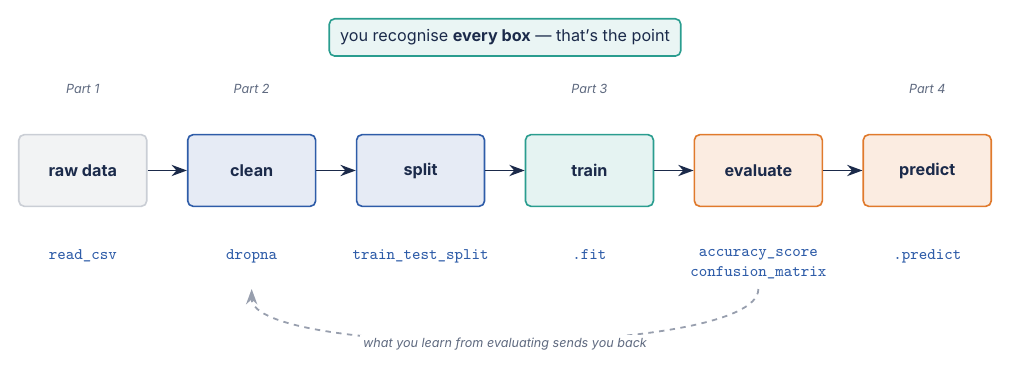
</p>

### Three next steps

1. **A course** — *[fill in your recommendation]*
2. **A dataset** — find one you actually care about and run this exact
   pipeline on it. That is how this becomes yours rather than ours.
3. **A community** — *[fill in your recommendation]*

> The most valuable thing you can take from today is not `.fit()`. It is the
> habit of looking at a prediction the model got **wrong** before believing
> the ones it got right.